In [1]:
import numpy as np 
import osmnx as osm
import networkx as nx
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm

from fn_lib import *
from indCity_fns import * 

plt.rcParams['text.usetex'] = True

# Cities

In [3]:
city_codes = [
    "DEL",
    "MUM",
    "KOL",
    "CHE",
    "BLR",
    "HYD",
    "PUN",
    "AHM",
    "JAI",
    "CHD",
    "LKO",
    "COK",
    "BPL",
    "IND",
    "NAG",
    "VIZ"
]

In [5]:
for city in city_codes:
    G = OpenGraph(city)
    V= nx.number_of_nodes(G)
    print(city, V)

DEL 183351
MUM 25612
KOL 35703
CHE 68414
BLR 154496
HYD 137247
PUN 32909
AHM 67816
JAI 110261
CHD 12137
LKO 69244
COK 13788
BPL 66036
IND 66250
NAG 39852
VIZ 38567


# Analysis on ind cities

In [2]:
# loading the data
city = "CHE"
datafile = f"RW_{city}_n100000_t10000.npz"
data = np.load(f"./RW_data/{datafile}")
X = data['X']; 
idx2nodes = data['idx2node']



In [3]:

G0 = OpenGraph(city) 

## Occupancy distribution for sync-random walk. 

100%|██████████| 1/1 [00:30<00:00, 30.99s/it]


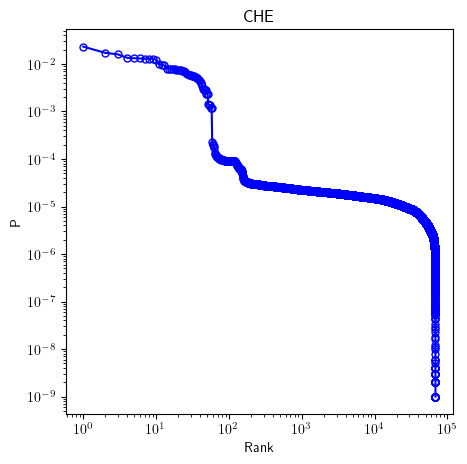

In [5]:
cities = os.listdir("./RW_data")
for city in tqdm(cities, total=len(cities)):
    X = np.load(f"./RW_data/{city}")['X']
    fig, ax = OccPDF(X)
    ax.set_title(city[3:6])
    fig.savefig(f"./OccPDFs/{city[:-4]}.png", dpi=450)
    plt.cla
    del X

## On real space

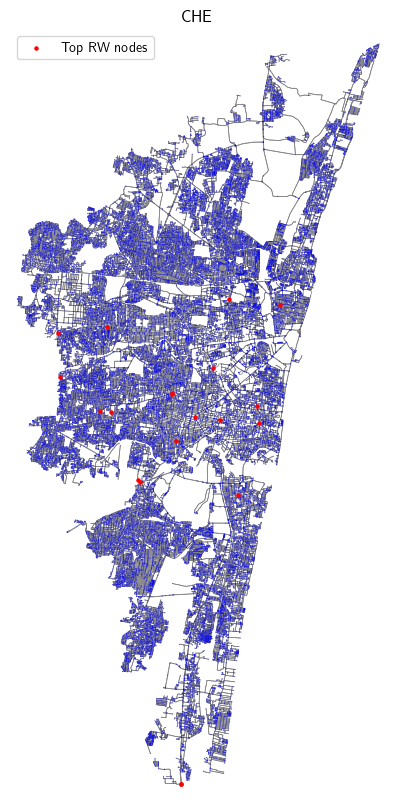

In [4]:
# datafile = "RW_CHE_n100000_t10000.npz"
# city = "CHE"
# G0 = OpenGraph(city) 
# data = np.load(f"./RW_data/{datafile}")
# X = data['X']; 
# idx2nodes = data['idx2node']
topNPlotMap(city, X, idx2nodes)

# Cities pooled analysis

100%|██████████| 16/16 [01:22<00:00,  5.18s/it]


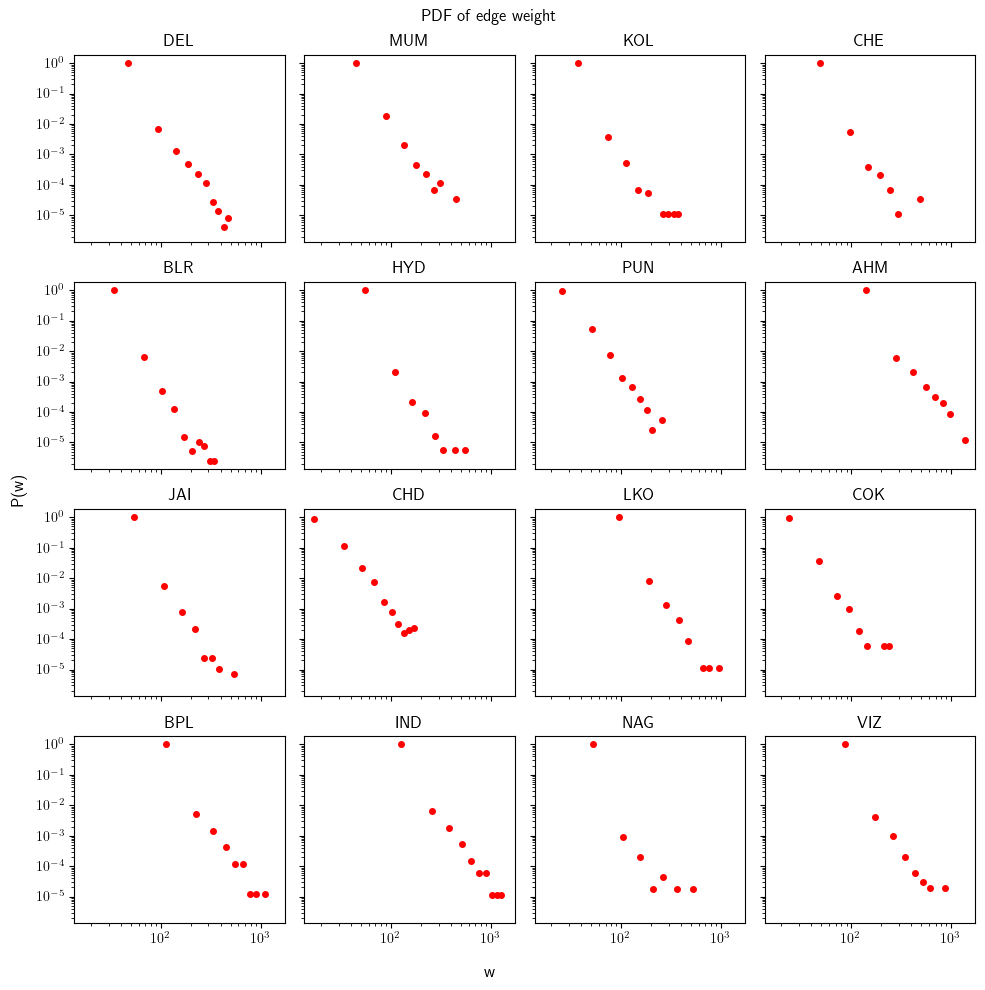

In [ ]:
a, b = wPDF(city_codes)
a.supxlabel("w")        # common X label
a.supylabel("P(w)")     # common Y label
    
a.suptitle("PDF of edge weight")
a.tight_layout()
a.savefig("time_dist.png", dpi=450)

100%|██████████| 16/16 [00:26<00:00,  1.63s/it]


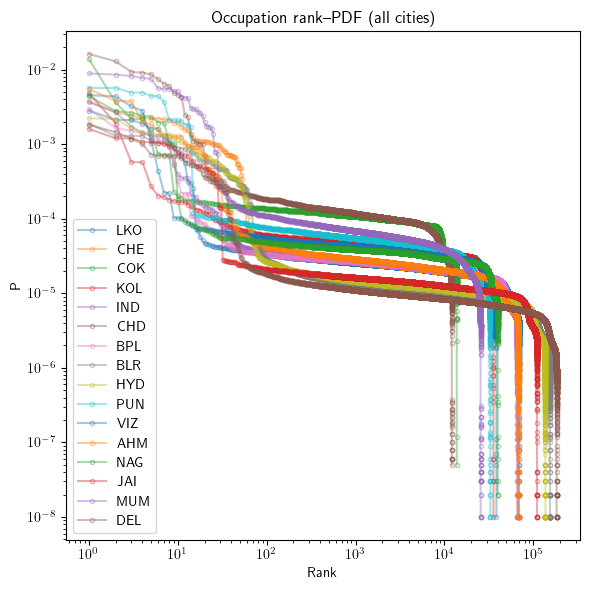

In [ ]:
def OccPDF(X, ax, label=None, alpha=0.4):
    counts = np.bincount(X.ravel())
    P = counts / counts.sum()
    P = P[P > 0]

    rankdP = np.sort(P)[::-1]
    ranks = np.arange(1, len(rankdP) + 1)

    ax.loglog(
        ranks, rankdP,
        'o-', markersize=3,
        fillstyle='none',
        alpha=alpha,
        label=label
    )

cities = os.listdir("./RW_data")

fig, ax = plt.subplots(figsize=(6, 6))

for city in tqdm(cities):
    X = np.load(f"./RW_data/{city}")['arr']
    OccPDF(X, ax, label=city[3:6])
    del X

ax.set_xlabel("Rank")
ax.set_ylabel("P")
ax.set_title("Occupation rank–PDF (all cities)")
plt.legend()

# optional legend (disable if too crowded)
# ax.legend(fontsize=6, ncol=3)

fig.tight_layout()
# fig.savefig("./OccPDFs/OccPDF_all_cities.png", dpi=450)
plt.show()
